In [24]:
from pymavlink import mavutil
import pandas as pd

log = mavutil.mavlink_connection("00000001.BIN")
log1 = mavutil.mavlink_connection("00000019.BIN")

types = set()

while True:
    msg = log1.recv_match(blocking=False)

    if msg is None:
        break

    types.add(msg.get_type())

print(types)

{'EV', 'GPS', 'FMTU', 'DCM', 'BARO', 'MAVC', 'STAT', 'VIBE', 'CTUN', 'PIDR', 'VER', 'IMU', 'FMT', 'MULT', 'FILE', 'GPA', 'UNIT', 'SIM2', 'PM', 'SIM', 'AOA', 'MODE', 'DSF', 'MSG', 'EAHR', 'UART', 'PIDY', 'FSTG', 'ATT', 'MAV', 'RELY', 'PARM', 'PIDP'}


In [ ]:
data = []

while True:
    msg = log1.recv_match(type=['GPS', 'ATT', 'IMU'], blocking=False)

    if msg is None:
        break

    if msg.get_type() == 'GPS':
        data.append({
            "time": msg.TimeUS,
            "lat": msg.Lat,
            "lon": msg.Lng,
            "alt": msg.Alt,
            "speed": msg.Spd
        })

df = pd.DataFrame(data)
print(df.columns)
print(df.head(20))

Index(['time', 'lat', 'lon', 'alt', 'speed'], dtype='object')
        time        lat         lon     alt  speed
0   50814626 -35.363265  149.165237  584.85  0.000
1   51014626 -35.363265  149.165237  584.85  0.000
2   51214626 -35.363265  149.165237  584.85  0.000
3   51414626 -35.363265  149.165237  584.85  0.002
4   51614626 -35.363265  149.165237  584.85  0.002
5   51814626 -35.363265  149.165237  584.85  0.000
6   52014626 -35.363265  149.165237  584.85  0.000
7   52214626 -35.363265  149.165237  584.85  0.000
8   52414626 -35.363265  149.165237  584.85  0.000
9   52614626 -35.363265  149.165237  584.85  0.000
10  52814626 -35.363265  149.165237  584.85  0.000
11  53014626 -35.363265  149.165237  584.85  0.000
12  53214626 -35.363265  149.165237  584.85  0.000
13  53414626 -35.363265  149.165237  584.85  0.002
14  53614626 -35.363265  149.165237  584.85  0.002
15  53814626 -35.363265  149.165237  584.85  0.000
16  54014626 -35.363265  149.165237  584.85  0.000
17  54214626 -35.363

In [30]:
data1 = []

while True:
    msg = log1.recv_match(type=['GPS', 'ATT', 'IMU'], blocking=False)

    if msg is None:
        break

    if msg.get_type() == 'GPS':
        data1.append({
            "time": msg.TimeUS,
            "lat": msg.Lat,
            "lon": msg.Lng,
            "alt": msg.Alt,
            "speed": msg.Spd
        })

df1 = pd.DataFrame(data1)
print(df1.columns)
print(df1.head(20))

Index(['time', 'lat', 'lon', 'alt', 'speed'], dtype='object')
        time        lat         lon      alt      speed
0   16463383 -35.148796  148.256957   774.02  44.981003
1   16643321 -35.364170  149.165228   787.28  45.020000
2   16843253 -35.364250  149.165227   804.12  44.554001
3   17043184 -35.364330  149.165225   820.58  44.101002
4   17243115 -35.364409  149.165224   836.68  43.662003
5   17443046 -35.364487  149.165222   852.39  43.235001
6   17642977 -35.364564  149.165221   867.77  42.818001
7   17842909 -35.364641  149.165219   882.78  42.413002
8   18042840 -35.364717  149.165217   897.37  42.018002
9   18242771 -35.364792  149.165216   911.58  41.632004
10  18442702 -35.364866  149.165214   925.42  41.255001
11  18642633 -35.364940  149.165212   938.89  40.885002
12  18842565 -35.365013  149.165210   951.98  40.522003
13  19043496 -35.365086  149.165208   964.70  40.165001
14  19243427 -35.365158  149.165207   977.06  39.812000
15  19443358 -35.365229  149.165204   989.

In [35]:
log1 = mavutil.mavlink_connection("00000019.BIN")


gps_data = []
imu_data = []
att_data = []
mode_data = []

while True:
    msg = log1.recv_match(blocking=False)

    if msg is None:
        break

    msg_type = msg.get_type()

    # ---------------- GPS ----------------
    if msg.get_type() == "GPS":

        gps_data.append({
            "time": msg.TimeUS,
            "lat": msg.Lat,
            "lon": msg.Lng,
            "alt": msg.Alt,
            "speed": msg.Spd
        })

    # ---------------- IMU ----------------
    elif msg_type == "IMU":
        imu_data.append({
            "time": msg.TimeUS,
            "AccX": msg.AccX,
            "AccY": msg.AccY,
            "AccZ": msg.AccZ,
            "GyrX": msg.GyrX,
            "GyrY": msg.GyrY,
            "GyrZ": msg.GyrZ
        })

    # ---------------- ATT ----------------
    elif msg_type == "ATT":
        att_data.append({
            "time": msg.TimeUS,
            "roll": msg.Roll,
            "pitch": msg.Pitch,
            "yaw": msg.Yaw
        })

    # ---------------- MODE ----------------
    elif msg_type == "MODE":
        mode_data.append({
            "time": msg.TimeUS,
            "mode": msg.Mode
        })

# Convert to DataFrames
gps_df = pd.DataFrame(gps_data)
imu_df = pd.DataFrame(imu_data)
att_df = pd.DataFrame(att_data)
mode_df = pd.DataFrame(mode_data)


# Sort by time (required for synchronization)
gps_df = gps_df.sort_values("time")
imu_df = imu_df.sort_values("time")
att_df = att_df.sort_values("time")
mode_df = mode_df.sort_values("time")

# ---------------- Synchronization ----------------

# Start with GPS timeline
merged = pd.merge_asof(
    gps_df,
    imu_df,
    on="time",
    direction="nearest"
)

merged = pd.merge_asof(
    merged,
    att_df,
    on="time",
    direction="nearest"
)

merged = pd.merge_asof(
    merged,
    mode_df,
    on="time",
    direction="nearest"
)

merged["time_sec"] = (
    merged["time"] - merged["time"].iloc[0]
) / 1e6

print(merged.head(10))

       time        lat         lon     alt      speed      AccX      AccY  \
0  16463383 -35.148796  148.256957  774.02  44.981003 -0.707038 -0.004848   
1  16643321 -35.364170  149.165228  787.28  45.020000 -0.696021 -0.008910   
2  16843253 -35.364250  149.165227  804.12  44.554001 -0.667507 -0.045205   
3  17043184 -35.364330  149.165225  820.58  44.101002 -0.648939 -0.026318   
4  17243115 -35.364409  149.165224  836.68  43.662003 -0.635748 -0.007870   
5  17443046 -35.364487  149.165222  852.39  43.235001 -0.619270 -0.037837   
6  17642977 -35.364564  149.165221  867.77  42.818001 -0.601526 -0.066068   
7  17842909 -35.364641  149.165219  882.78  42.413002 -0.593629 -0.034881   
8  18042840 -35.364717  149.165217  897.37  42.018002 -0.578997 -0.048625   
9  18242771 -35.364792  149.165216  911.58  41.632004 -0.564656 -0.059552   

       AccZ      GyrX      GyrY      GyrZ      roll      pitch         yaw  \
0 -2.310431 -0.018767 -0.023227  0.004653  4.060510  64.000267  359.223419

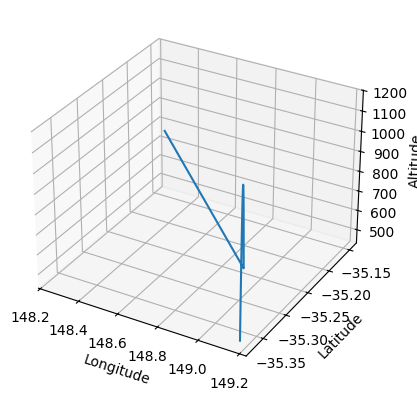

In [36]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(merged['lon'], merged['lat'], merged['alt'])
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude')
plt.show()